# EDA: Fashion-MNIST (Autoencoder-spåret)

Utforskande dataanalys av datasetet vi använder för denoising-autoencodern.
Syfte: förstå datasetets storlek, klassbalans och hur bruset vi lägger på
faktiskt påverkar bilderna, innan vi tolkar modellresultaten.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from data_prep import CLASS_NAMES, load_data, normalize, add_noise, NOISE_FACTOR

(x_train, y_train), (x_test, y_test) = load_data()
print(f"train: {x_train.shape}, test: {x_test.shape}")
print(f"pixel range: {x_train.min()} - {x_train.max()} (raw, before normalisering)")


train: (60000, 28, 28), test: (10000, 28, 28)
pixel range: 0 - 255 (raw, before normalisering)


## Datasetöversikt

Fashion-MNIST innehåller 70 000 gråskalebilder (28x28 px) av klädesplagg,
fördelat på 10 kategorier. 60 000 bilder används för träning, 10 000 för test
(vi delar sedan av en valideringsmängd från träningsdelen i `data_prep.py`).


In [2]:
print(f"Antal träningsbilder: {len(x_train)}")
print(f"Antal testbilder: {len(x_test)}")
print(f"Bildstorlek: {x_train.shape[1]}x{x_train.shape[2]} pixlar, gråskala")
print(f"Antal klasser: {len(CLASS_NAMES)}")
print(f"Klasser: {CLASS_NAMES}")


Antal träningsbilder: 60000
Antal testbilder: 10000
Bildstorlek: 28x28 pixlar, gråskala
Antal klasser: 10
Klasser: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Klassbalans

Är datasetet balanserat mellan de 10 kategorierna?

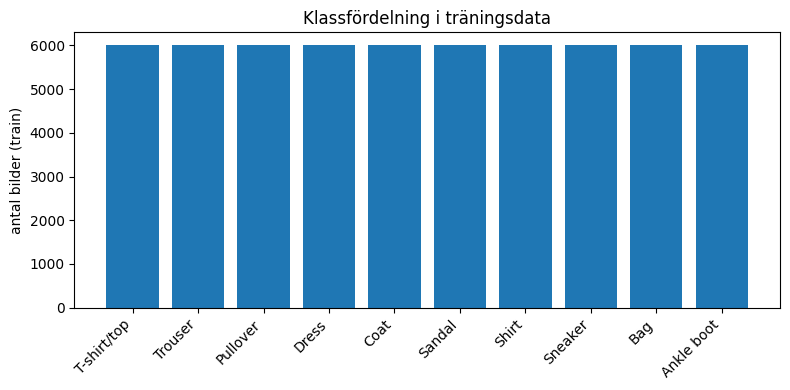

Min: 6000, Max: 6000 -> balanserat


In [3]:
counts = np.bincount(y_train)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(CLASS_NAMES, counts)
ax.set_ylabel("antal bilder (train)")
ax.set_title("Klassfördelning i träningsdata")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/eda_class_distribution.png")
plt.show()

print(f"Min: {counts.min()}, Max: {counts.max()} -> {'balanserat' if counts.max() - counts.min() < 100 else 'obalanserat'}"
)

**Slutsats:** datasetet är perfekt balanserat (6000 bilder per klass i träningsdata).
Det betyder att vi inte behöver oroa oss för klassobalans i denoising-uppgiften -
autoencodern får se lika mycket av varje klädkategori under träning.


## Exempelbilder per klass

En bild från varje kategori, för att se vad modellen faktiskt jobbar med.

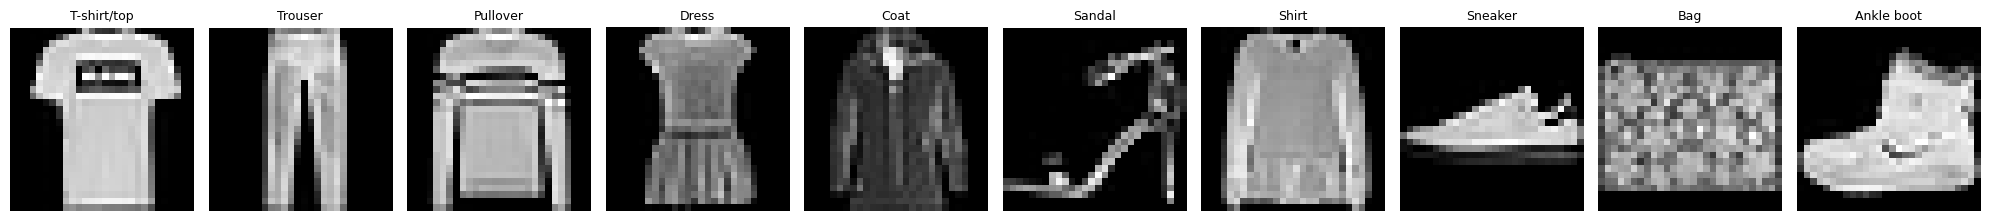

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for class_id in range(10):
    idx = np.where(y_train == class_id)[0][0]
    axes[class_id].imshow(x_train[idx], cmap="gray")
    axes[class_id].set_title(CLASS_NAMES[class_id], fontsize=9)
    axes[class_id].axis("off")
plt.tight_layout()
plt.savefig("../reports/eda_example_per_class.png")
plt.show()


## Pixelvärdesfördelning

Kollar hur pixelvärdena är fördelade före normalisering - viktigt för att
förstå varför vi skalar till [0, 1] i `data_prep.py`.


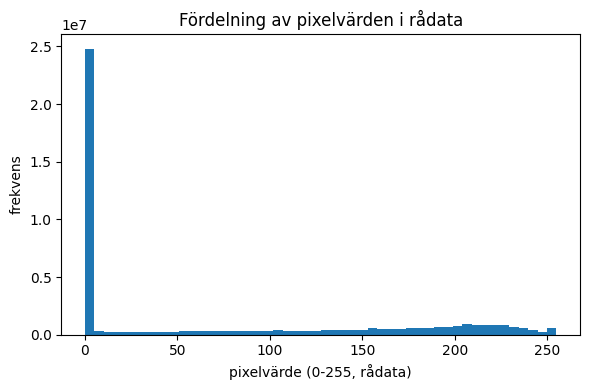

Andel svarta (0-värde) pixlar: 50.2% - mestadels svart bakgrund runt plaggen


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(x_train.flatten(), bins=50)
ax.set_xlabel("pixelvärde (0-255, rådata)")
ax.set_ylabel("frekvens")
ax.set_title("Fördelning av pixelvärden i rådata")
plt.tight_layout()
plt.savefig("../reports/eda_pixel_distribution.png")
plt.show()

zero_fraction = (x_train == 0).mean()
print(f"Andel svarta (0-värde) pixlar: {zero_fraction:.1%} - mestadels svart bakgrund runt plaggen")


## Effekten av brus

Vi lägger på Gaussiskt brus (`NOISE_FACTOR = 0.3`) för att skapa denoising-uppgiften.
Här jämför vi olika brusnivåer för att motivera valet.


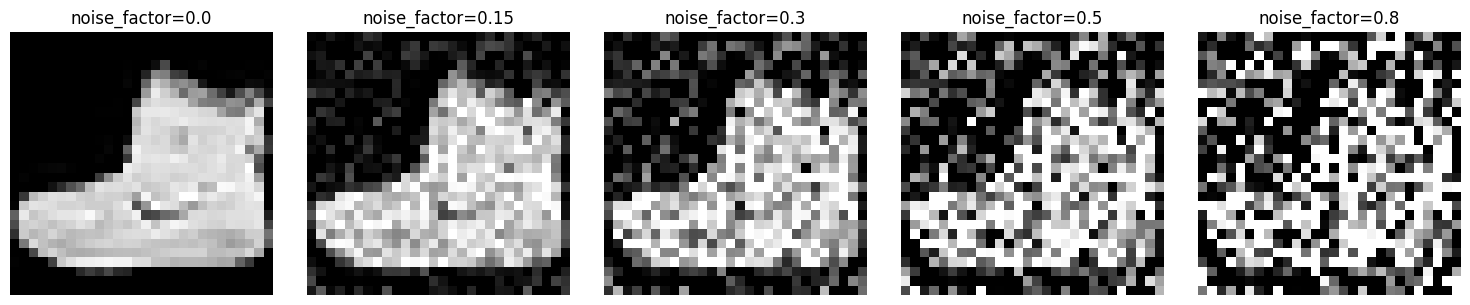

In [6]:
x_sample = normalize(x_train[:1])
noise_levels = [0.0, 0.15, 0.3, 0.5, 0.8]

fig, axes = plt.subplots(1, len(noise_levels), figsize=(15, 3))
for ax, level in zip(axes, noise_levels):
    noisy = add_noise(x_sample, noise_factor=level, rng=np.random.default_rng(0))
    ax.imshow(noisy[0].squeeze(), cmap="gray")
    ax.set_title(f"noise_factor={level}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("../reports/eda_noise_levels.png")
plt.show()


**Slutsats:** `NOISE_FACTOR = 0.3` (använt i `data_prep.py`) gör bilderna klart
brusiga men plagget är fortfarande urskiljbart för ögat - en rimlig svårighetsgrad.
Vid `0.8` blir bilden nästan oigenkännlig, vilket hade gjort uppgiften orimligt svår.

## Sammanfattning för gruppen

- Datasetet är balanserat (6000 bilder/klass) - ingen särskild hantering av klassobalans behövs.
- Bildernas bakgrund är nästan helt svart (pixelvärde 0), plagget upptar en begränsad del av bilden.
- `NOISE_FACTOR = 0.3` ger en rimlig denoising-svårighetsgrad - värt att nämna i presentationen
  som en medveten designval, inte en slumpmässig parameter.
- Nästa steg: modellperson kan använda dessa insikter för att avgöra om fler/färre filter behövs,
  och presentationspersonen kan återanvända `eda_example_per_class.png` och `eda_noise_levels.png`
  i databerättelsen (dataset-delen av presentationen).
